<a href="https://colab.research.google.com/github/komarrenuka/Individual-Task-AML-/blob/main/083IT(AML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:

#Load the Dataset
df = pd.read_csv("BankNote_Authentication.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Shape: (1372, 5)

Columns: ['variance', 'skewness', 'curtosis', 'entropy', 'class']

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [ ]:
#Check Class Distribution
print("Class distribution:")
print(df["class"].value_counts())

Class distribution:
class
0    762
1    610
Name: count, dtype: int64


In [ ]:
#Separate Features and Target
X = df.drop("class", axis=1)
y = df["class"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   variance  skewness  curtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880

Target:
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64


In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1097
Testing samples: 275


In [ ]:
#Feature Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


In [ ]:
#Naive Bayes
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Predictions:")
print(y_pred_nb)

Naive Bayes Predictions:
[0 1 0 1 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0
 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0
 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1
 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 0
 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1 0 0
 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1
 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0
 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0]


In [ ]:
#Naive Bayes Evaluation
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Metrics")
print("-------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

Naive Bayes Metrics
-------------------
Accuracy : 0.8582
Precision: 0.8487
Recall   : 0.8279
F1 Score : 0.8382


In [ ]:
# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Forged", "Genuine"]
    )
)

Naive Bayes Confusion Matrix:
[[135  18]
 [ 21 101]]

Classification Report:
              precision    recall  f1-score   support

      Forged       0.87      0.88      0.87       153
     Genuine       0.85      0.83      0.84       122

    accuracy                           0.86       275
   macro avg       0.86      0.86      0.86       275
weighted avg       0.86      0.86      0.86       275



SVM


In [ ]:
# Train SVM
svm = SVC(kernel="linear")

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
[0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0
 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1
 1 0 0 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1
 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0
 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1
 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0]


In [ ]:
#SVM Evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Metrics")
print("-----------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1 Score :", round(f1_svm, 4))

SVM Metrics
-----------
Accuracy : 0.9745
Precision: 0.9457
Recall   : 1.0
F1 Score : 0.9721


In [ ]:
#SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Forged", "Genuine"]
    )
)

SVM Confusion Matrix:
[[146   7]
 [  0 122]]

Classification Report:
              precision    recall  f1-score   support

      Forged       1.00      0.95      0.98       153
     Genuine       0.95      1.00      0.97       122

    accuracy                           0.97       275
   macro avg       0.97      0.98      0.97       275
weighted avg       0.98      0.97      0.97       275



In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Find the best K value
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

# Select the best K
best_k = k_values[np.argmax(cv_scores)]

print("Best K value:", best_k)
print("Best Cross-Validation Accuracy:", max(cv_scores))


# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=best_k)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict test data
knn_pred = knn_model.predict(X_test_scaled)


# Evaluate KNN
accuracy = accuracy_score(y_test, knn_pred)
precision = precision_score(y_test, knn_pred)
recall = recall_score(y_test, knn_pred)
f1 = f1_score(y_test, knn_pred)

print("\n===== K-NEAREST NEIGHBORS =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Best K value: 1
Best Cross-Validation Accuracy: 0.9981776670817768

===== K-NEAREST NEIGHBORS =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate performance of all three algorithms

results = pd.DataFrame({
    "Algorithm": [
        "Naive Bayes",
        "SVM",
        "KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, knn_pred)
    ],

    "Precision": [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, knn_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, knn_pred)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, knn_pred)
    ]
})

print("===== MODEL COMPARISON =====")
print(results)

===== MODEL COMPARISON =====
     Algorithm  Accuracy  Precision    Recall  F1-Score
0  Naive Bayes  0.858182   0.848739  0.827869  0.838174
1          SVM  0.974545   0.945736  1.000000  0.972112
2          KNN  1.000000   1.000000  1.000000  1.000000


In [ ]:
#Find the Best Algorithm
# Find the algorithm with the highest accuracy

best_algorithm = results.loc[
    results["Accuracy"].idxmax(),
    "Algorithm"
]

best_accuracy = results["Accuracy"].max()

print("\n===== BEST ALGORITHM =====")
print("Best Algorithm:", best_algorithm)
print("Best Accuracy:", best_accuracy)


===== BEST ALGORITHM =====
Best Algorithm: KNN
Best Accuracy: 1.0


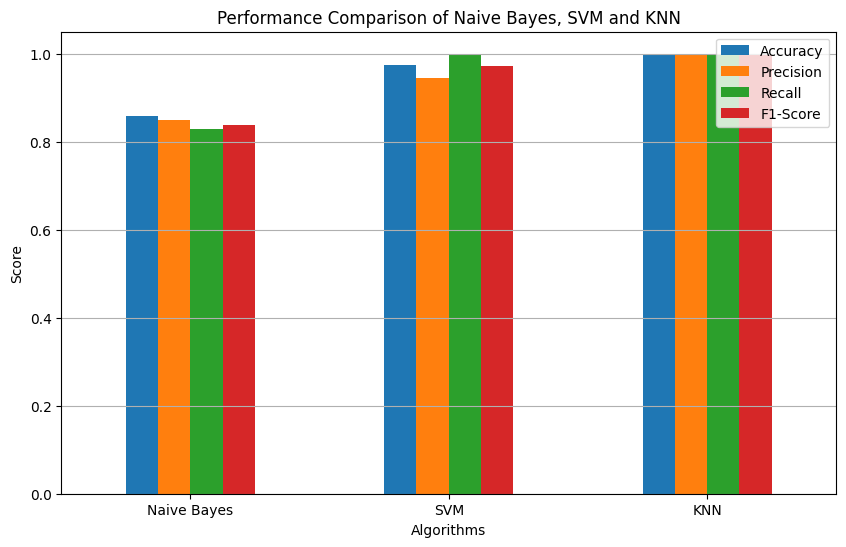

In [ ]:
#Graphical Comparison
import matplotlib.pyplot as plt

# Select metrics for comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Plot comparison
results.set_index("Algorithm")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Naive Bayes, SVM and KNN")
plt.xlabel("Algorithms")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")

plt.show()

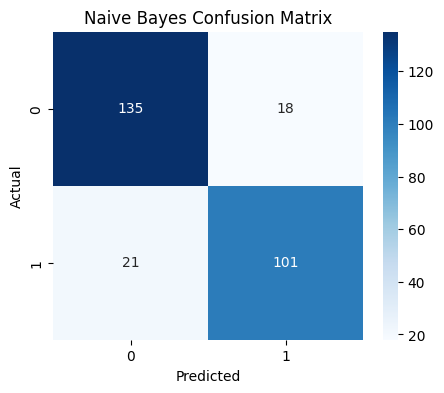

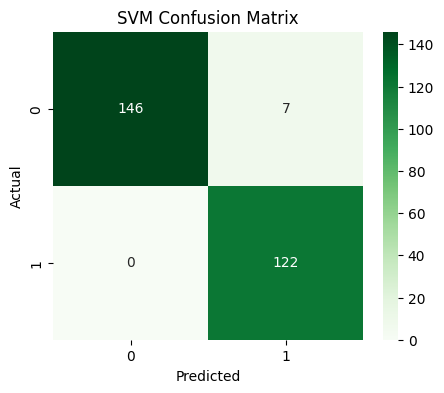

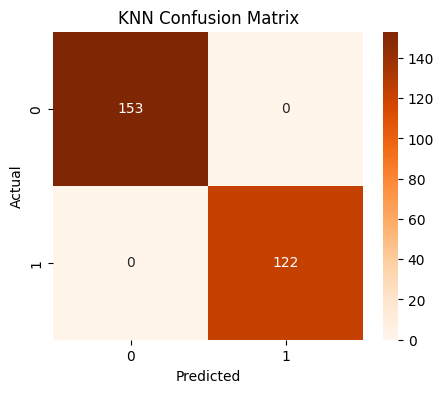

In [ ]:
#Confusion Matrix for All 3 Algorithms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrices
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_knn = confusion_matrix(y_test, knn_pred)


# Naive Bayes Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# SVM Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# KNN Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Oranges")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#Predict a New Banknote
# New banknote feature values
# [Variance, Skewness, Curtosis, Entropy]

new_banknote_data = [
    2.5,      # Variance
    7.3,      # Skewness
    -1.2,     # Curtosis
    -0.5      # Entropy
]

# Convert new banknote data to a DataFrame with feature names
new_banknote = pd.DataFrame([new_banknote_data], columns=X.columns)

# Scale the new data
new_banknote_scaled = scaler.transform(new_banknote)


# Prediction using Naive Bayes
nb_result = nb.predict(new_banknote_scaled)

# Prediction using SVM
svm_result = svm.predict(new_banknote_scaled)

# Prediction using KNN
knn_result = knn_model.predict(new_banknote_scaled)


# Convert prediction into label
def banknote_label(result):
    if result[0] == 1:
        return "Genuine Banknote"
    else:
        return "Forged Banknote"


print("===== BANKNOTE AUTHENTICITY PREDICTION =====")

print("Naive Bayes:", banknote_label(nb_result))
print("SVM        :", banknote_label(svm_result))
print("KNN        :", banknote_label(knn_result))

===== BANKNOTE AUTHENTICITY PREDICTION =====
Naive Bayes: Forged Banknote
SVM        : Forged Banknote
KNN        : Forged Banknote
